# Lab01 — Cotizaciones óptimas de un formador de mercado

**Microestructuras y Sistemas de Trading (IT1731B) — Otoño 2026 — Equipo 6**

Modelo de Copeland y Galai (1983): un formador de mercado publica un Bid y un Ask alrededor de
un precio de referencia S0, y elige esas cotizaciones para maximizar su utilidad esperada por
trade. Frente a un trader de liquidez gana el medio spread, porque ese trader opera por razones
ajenas al valor del activo. Frente a un trader informado pierde, porque el informado solo cruza
cuando el valor verdadero está fuera de las cotizaciones publicadas. Ensanchar el spread protege
de la selección adversa pero espanta flujo de liquidez: ese es el trade-off que se optimiza.

Este notebook **solo importa funciones de `src/` y genera figuras**. Toda la lógica del modelo,
la simulación de trades y la construcción de las figuras vive en `src/model.py`,
`src/simulation.py` y `src/plots.py`.

**Estructura:** planteamiento → optimización → simulación y comparación → sensibilidad →
conclusiones.


In [1]:
# Bootstrap del entorno: agrega la raiz del repositorio a sys.path para poder
# importar `src` sin importar si el notebook se abre desde `notebooks/` o
# desde la raiz. No es logica del proyecto, es plomeria de imports.
import pathlib
import sys

for candidato in (pathlib.Path.cwd(), pathlib.Path.cwd().parent):
    if (candidato / "src").is_dir() and str(candidato) not in sys.path:
        sys.path.insert(0, str(candidato))


## 1. Planteamiento

Parámetros del caso base, fijos por el enunciado y definidos una sola vez en `src/model.py`:

| Parámetro | Valor |
|---|---|
| Precio de referencia S0 | 19.90 |
| Valor verdadero del activo | Erlang(k=60, λ=3) — media 20.0, desviación estándar 2.582 |
| Probabilidad de trader informado (pi_i) | 0.40 |
| Demanda de liquidez por lado | max(0, 0.50 − 0.08·s), con s el medio spread |
| Semilla del proyecto | 42 |

El precio de referencia (19.90) queda 0.10 por debajo de la media verdadera del activo (20.0):
ese sesgo no es casualidad — le da al trader informado algo que explotar incluso antes de que el
formador decida cuánto ensanchar sus cotizaciones.


In [2]:
import pandas as pd

from src.model import (
    S0,
    K_ERLANG,
    LAMBDA_ERLANG,
    PI_I,
    ALPHA,
    BETA,
    SEED,
    optimizar_cotizaciones,
    verificar_optimo_en_malla,
    analisis_sensibilidad,
)
from src.simulation import (
    construir_regimenes,
    simular_regimenes,
    monte_carlo_regimenes,
    resumen_monte_carlo,
)
from src.plots import (
    COLORES,
    ETIQUETAS_REGIMEN,
    fig_prob_ejecucion,
    fig_pnl_acumulado,
    fig_inventario,
    fig_histograma_montecarlo,
    fig_sensibilidad,
)


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 2. Optimización de las cotizaciones

Se resuelve `optimizar_cotizaciones()`: el bid y el ask que maximizan la utilidad esperada por
trade Pi(A, B) para `pi_i = 0.40`, sujetos a `A >= S0` y `0 < B <= S0`.


In [3]:
resultado_optimo = optimizar_cotizaciones()
pd.Series(resultado_optimo)


bid                                                         16.451678
ask                                                         23.427664
spread                                                       6.975986
utilidad_esperada                                            0.840285
pi_i                                                              0.4
convergio                                                        True
mensaje              CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
dtype: object

El bid óptimo queda bien por debajo de S0 y el ask bien por encima: el spread total ronda las 7
unidades. Esto pasa porque, aunque solo el 40% de los traders son informados, la Erlang(60, 3)
tiene suficiente dispersión (desviación estándar 2.58) como para que un spread angosto exponga al
formador a pérdidas frecuentes frente a ese 40%. El óptimo balancea esa protección contra la
ganancia que se deja de percibir del 60% de liquidez cuando el spread se ensancha demasiado.


In [4]:
verificacion_malla = verificar_optimo_en_malla(resultado_optimo)
pd.Series(verificacion_malla)


pi_i                   0.4
ask_malla            23.43
bid_malla            16.45
utilidad_malla    0.840284
dif_ask           0.002336
dif_bid           0.001678
coincide              True
dtype: object

Este barrido en malla fina es un chequeo independiente del optimizador basado en gradiente: como
las integrales de pérdida frente a informados tienen ruido numérico del orden de 1e-10, el
gradiente por diferencias finitas puede amplificarlo y desplazar ligeramente el óptimo reportado.
`coincide=True` confirma que el óptimo de la malla y el del optimizador prácticamente coinciden.


In [5]:
regimenes = construir_regimenes(resultado_optimo["bid"], resultado_optimo["ask"])
regimenes


{'optimo': (16.451678174551333, 23.427664257422613),
 'estrecho': (19.75, 20.05),
 'amplio': (18.4, 21.4)}

### Figura 1 — Probabilidad de ejecución vs. medio spread

Se superponen los tres regímenes sobre la curva teórica de `prob_ejecucion`, marcando el medio
spread de cada lado (ask − S0 y S0 − bid) con líneas punteadas del mismo color que el resto de las
figuras. Esta conversión de precio a medio spread es aritmética simple sobre valores que ya
calcularon `src.model` y `src.simulation` — no reimplementa ninguna fórmula del modelo.


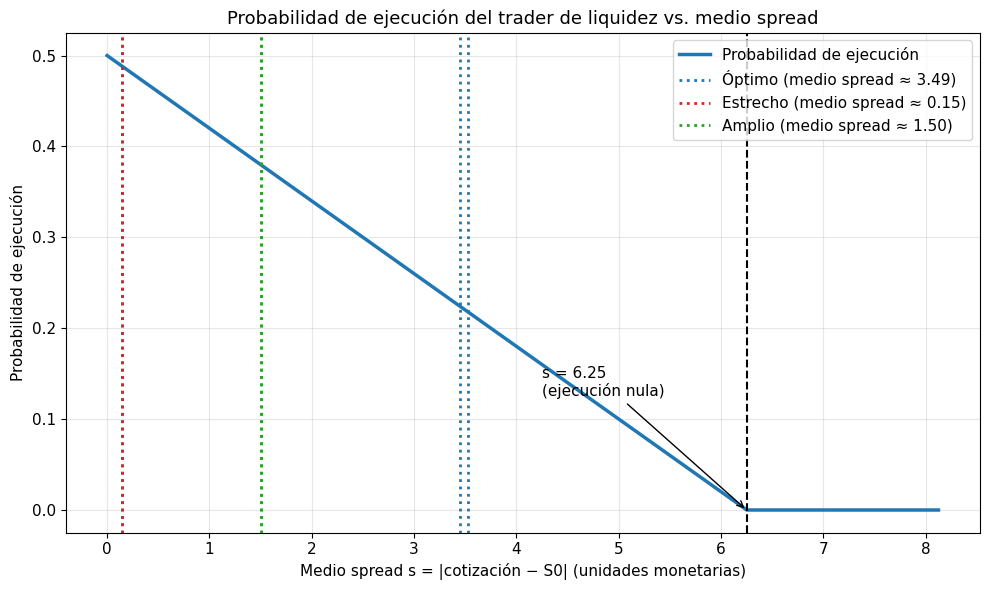

In [6]:
fig1 = fig_prob_ejecucion()
ax1 = fig1.axes[0]

for nombre, (bid, ask) in regimenes.items():
    color = COLORES[nombre]
    etiqueta = ETIQUETAS_REGIMEN[nombre]
    ax1.axvline(
        ask - S0,
        color=color,
        linestyle=":",
        linewidth=2,
        label=f"{etiqueta} (medio spread ≈ {(ask - S0 + S0 - bid) / 2:.2f})",
    )
    ax1.axvline(S0 - bid, color=color, linestyle=":", linewidth=2)

ax1.legend(fontsize=11);


Se ve de un vistazo que el régimen amplio (medio spread ≈ 1.50) sigue lejísimos de `s = 6.25`,
donde la ejecución de liquidez se anula: en ese régimen todavía llega bastante volumen, solo que a
una probabilidad más baja que en los otros dos. El régimen estrecho, con medio spread de apenas
0.15, casi no reduce la probabilidad de ejecución respecto al máximo (0.50 en s = 0) — es
exactamente esa combinación de spread angosto y alta probabilidad de ejecución la que lo deja tan
expuesto a la selección adversa que se observa en las figuras siguientes.


## 3. Simulación y comparación entre regímenes

Se simulan 10,000 trades por régimen con `forzar_ejecucion=True` (el default del enunciado): el
trader de liquidez siempre ejecuta. La advertencia obligatoria del enunciado aplica de lleno aquí
— estos resultados son rentabilidad **por trade**, no por unidad de tiempo, así que el régimen
amplio se ve mejor de lo que sería en la realidad, donde su baja probabilidad de ejecución
significaría muchos menos trades por unidad de tiempo que los otros dos regímenes.


In [7]:
simulaciones = simular_regimenes(regimenes, n_trades=10_000, seed=SEED)
simulaciones["optimo"].head()


,trade_id,tipo_trader,direccion,ejecutado,valor_verdadero,precio_ejecucion,pnl,delta_inventario,pnl_acumulado,inventario
0,0,liquidez,compra,True,15.423109,23.427664,3.527664,-1,3.527664,-1
1,1,liquidez,venta,True,23.092247,16.451678,3.448322,1,6.975986,0
2,2,liquidez,compra,True,21.261492,23.427664,3.527664,-1,10.503650,-1
3,3,liquidez,compra,True,20.518281,23.427664,3.527664,-1,14.031315,-2
4,4,informado,ninguna,False,21.535128,NaN,0.000000,0,14.031315,-2


Cada fila es un trade: tipo de trader, dirección desde su perspectiva, si se ejecutó, el precio de
ejecución y el P&L y cambio de inventario que le deja al formador. Las columnas `pnl_acumulado` e
`inventario` son las que alimentan las Figuras 2 y 3.


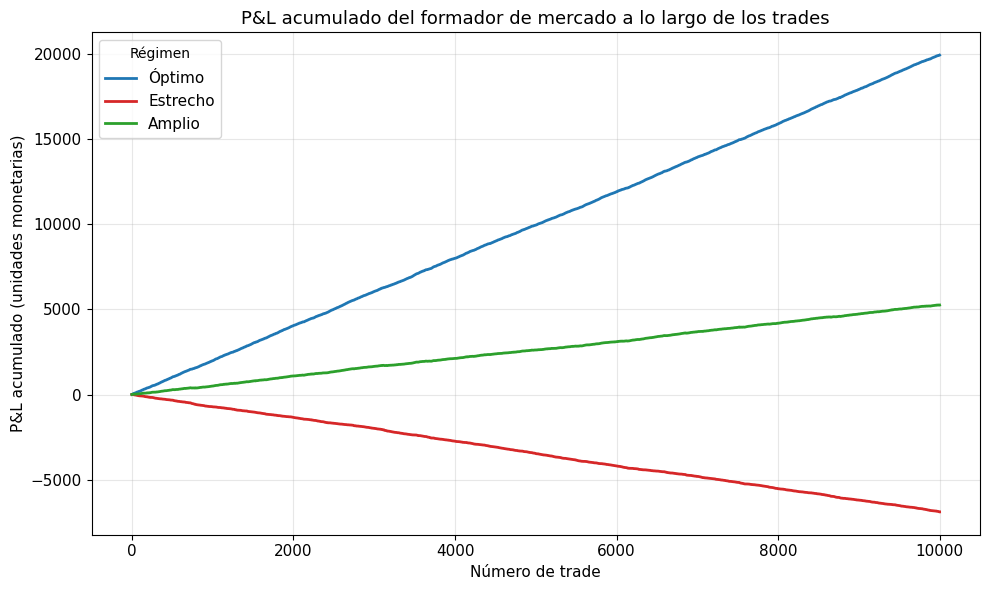

In [8]:
fig2 = fig_pnl_acumulado(simulaciones)


In [9]:
{nombre: round(df["pnl_acumulado"].iloc[-1], 2) for nombre, df in simulaciones.items()}


{'optimo': np.float64(19911.79),
 'estrecho': np.float64(-6887.78),
 'amplio': np.float64(5246.39)}

El régimen óptimo termina claramente arriba de los otros dos. El estrecho cierra en terreno
negativo: su medio spread de 0.15 es menor que la pérdida esperada por trade frente a un
informado, así que cada vez que un informado cruza, el formador pierde más de lo que gana en
varios trades de liquidez seguidos. El amplio termina positivo pero muy por debajo del óptimo,
porque protegerse de más también le cuesta: rechaza (en el sentido de baja probabilidad de
ejecución) ganancia de liquidez que el régimen óptimo sí captura.


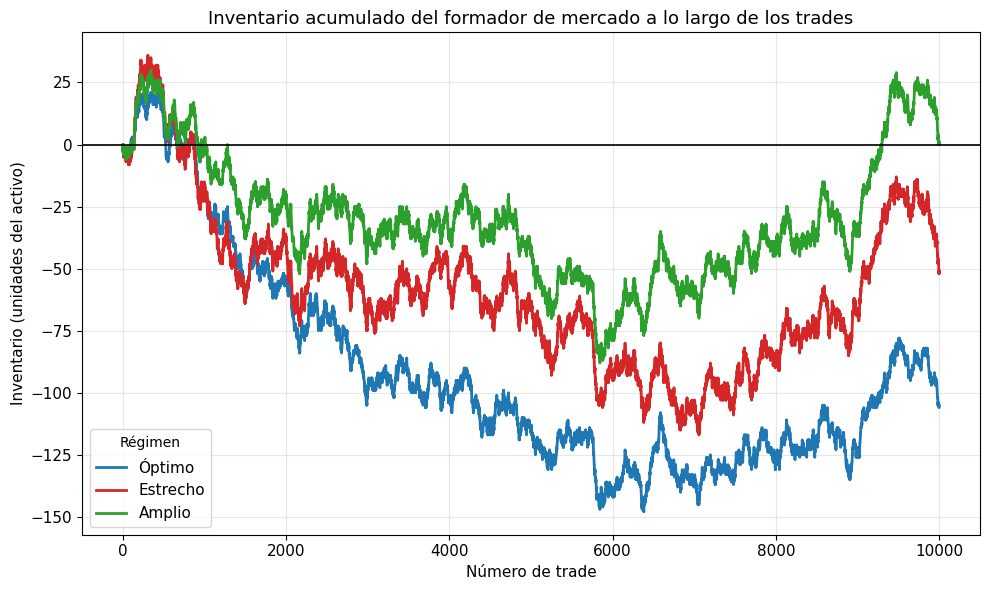

In [10]:
fig3 = fig_inventario(simulaciones)


El inventario del régimen amplio se mueve con menos amplitud que el de óptimo y estrecho. La
razón es la banda `B <= P <= A` donde el informado no tiene incentivo de operar (punto abierto O2):
esa banda es mucho más ancha en el régimen amplio, así que muchos menos trades de informados
llegan a ejecutarse ahí, y son justo los informados quienes presionan el inventario en una sola
dirección (los de liquidez son 50/50 y tienden a cancelarse entre sí).


### Análisis de Monte Carlo

In [11]:
resultados_mc = monte_carlo_regimenes(regimenes, n_corridas=1_000, n_trades=1_000, seed=SEED)
tabla_montecarlo = resumen_monte_carlo(resultados_mc)
tabla_montecarlo


,regimen,pnl_promedio,pnl_std,prob_perdida
0,optimo,2009.030273,60.442587,0.0
1,estrecho,-672.748677,45.713671,1.0
2,amplio,542.750416,46.378106,0.0


`pnl_promedio` y `pnl_std` son la media y la desviación estándar de las 1,000 corridas, no de los
trades individuales. El régimen estrecho pierde en prácticamente la totalidad de sus corridas: con
mil trades por corrida, la selección adversa tiene tiempo de acumularse y casi nunca se revierte.
Óptimo y amplio, en cambio, casi no pierden en esta muestra — su ventaja frente a informados es
suficiente para que mil trades casi siempre cierren en positivo.


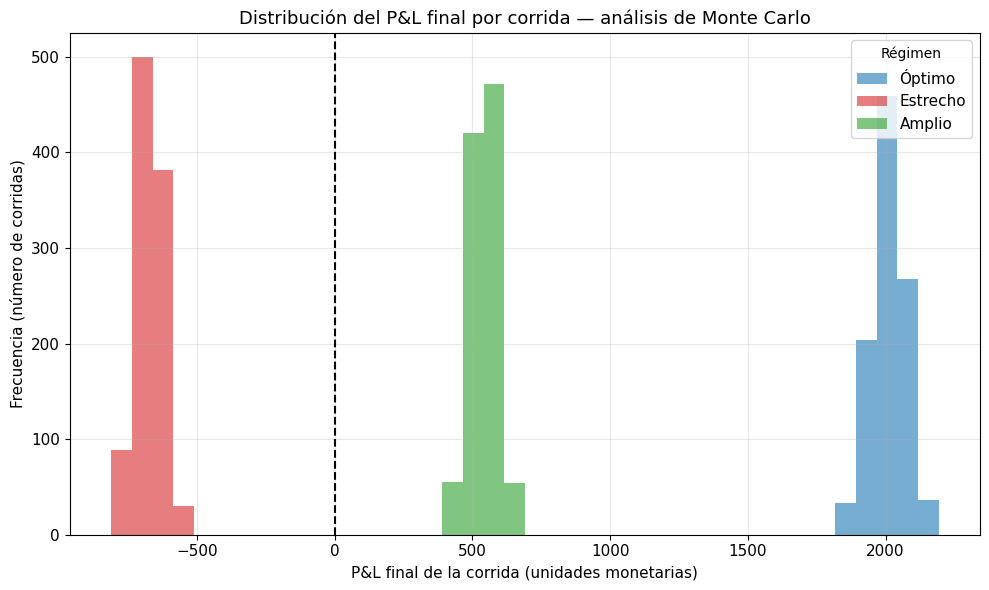

In [12]:
fig4 = fig_histograma_montecarlo(resultados_mc)


La línea vertical en cero hace visible lo mismo que reporta `prob_perdida`: para el régimen
estrecho, casi toda la masa del histograma queda a la izquierda de esa línea. Para óptimo y
amplio, la masa está casi enteramente a la derecha, y sus distribuciones ni siquiera se traslapan
con la del estrecho — la separación entre "proteger razonablemente" y "no proteger" el spread es
así de grande en este modelo.


## 4. Sensibilidad a la proporción de traders informados

Se reoptimiza el spread para `pi_i` en {0.1, 0.4, 0.7}, manteniendo todo lo demás fijo.


In [13]:
df_sensibilidad = analisis_sensibilidad()
df_sensibilidad


,pi_i,bid,ask,spread,utilidad_esperada,convergio
0,0.1,16.708786,23.106476,6.397690,1.378707,True
1,0.4,16.451678,23.427664,6.975986,0.840285,True
2,0.7,16.006976,24.000839,7.993863,0.336625,True


El spread óptimo crece con `pi_i` y la utilidad esperada cae: a más traders informados, el
formador se defiende de la única forma que puede, ensanchando las cotizaciones, y eso a su vez le
espanta flujo de liquidez. La comparación contra la predicción teórica de la Sesión 04 queda
pendiente del punto abierto O3 — sin la fórmula exacta de esa sesión, aquí solo se reporta el
resultado numérico del modelo.


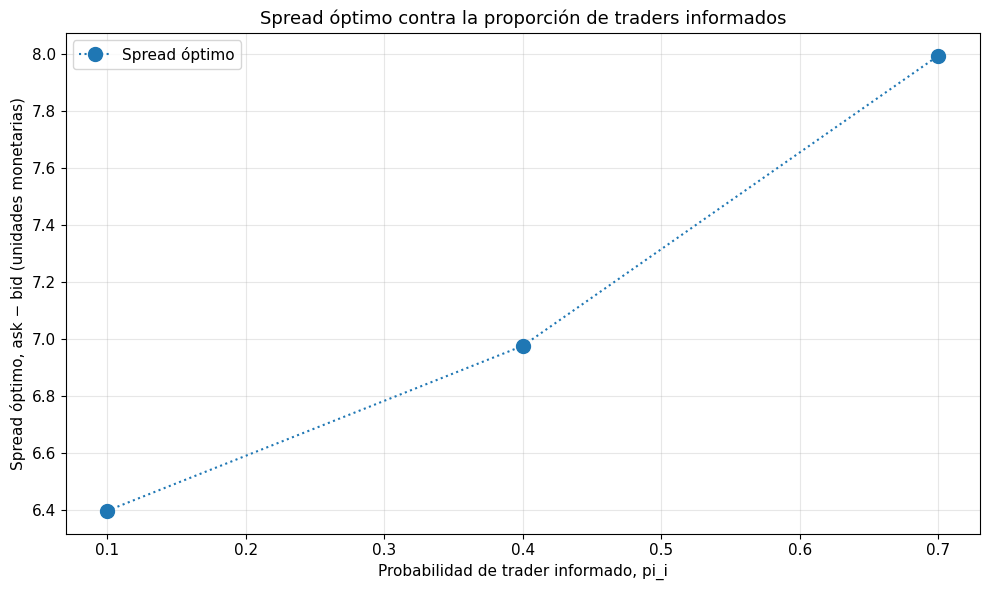

In [14]:
fig5 = fig_sensibilidad(df_sensibilidad)


Con solo tres puntos no hay evidencia suficiente para afirmar que la relación sea lineal — de
hecho no lo es exactamente, porque el spread depende de una integral no lineal de la Erlang — por
eso los tres puntos se conectan con una línea punteada y no una sólida. Ningún caso quedó marcado
como "no convergió", así que los tres óptimos de esta tabla son confiables.


## 5. Conclusiones

- **El spread óptimo le gana a los dos regímenes ingenuos.** El estrecho pierde dinero de forma
  sistemática porque no cobra lo suficiente por el riesgo de selección adversa; el amplio protege
  de más y deja sobre la mesa ganancia de liquidez que el óptimo sí captura.
- **La selección adversa es el mecanismo, no una etiqueta.** Se ve de punta a punta: en la Figura
  1 (el estrecho casi no reduce la probabilidad de ejecución de liquidez respecto al máximo), en
  las Figuras 2 y 3 (el estrecho se hunde en P&L acumulado y su inventario se mueve más que el del
  amplio) y en la Figura 4 (su probabilidad de pérdida en el Monte Carlo es prácticamente 1).
- **La rentabilidad reportada es por trade, no por unidad de tiempo.** Con `forzar_ejecucion=True`
  se ignora que el régimen amplio, en la realidad, ejecutaría muchos menos trades por unidad de
  tiempo que los otros dos regímenes — la ventaja del amplio frente al estrecho en estas cifras
  está inflada respecto a lo que pasaría con el reloj corriendo.
- **A más traders informados, más ancho el spread óptimo y menor la utilidad esperada.** Es la
  misma selección adversa escalando: el formador no tiene otra defensa disponible en este modelo
  más que ensanchar cotizaciones, y esa defensa tiene el costo de espantar flujo de liquidez.
- **Supuestos declarados:** la dirección del trader de liquidez se sortea 50/50 e independiente del
  spread (P2); el informado sin incentivo dentro de la banda `B <= P <= A` no opera (punto abierto
  O2); la reproducibilidad usa `numpy.random.default_rng(SEED)` en vez del generador global (punto
  abierto O7). Los tres están documentados en `CLAUDE.md` y en `docs/instrucciones/`.
